# LGBM 05 — Evaluation

Load generated metrics and predictions and visualize performance without retraining.

In [1]:
# Import libraries
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "forecasting" / "lightgbm"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "forecasting" / "lightgbm"

REPORTS_DIR, OUTPUTS_DIR


(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/forecasting/lightgbm'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/lightgbm'))

In [3]:
# Get model metrics
global_metrics = pd.read_csv(REPORTS_DIR / "LGBM_05_global_metrics.csv")
fold_metrics = pd.read_csv(REPORTS_DIR / "LGBM_05_fold_metrics.csv")
fsa_metrics = pd.read_csv(REPORTS_DIR / "LGBM_05_fsa_metrics.csv")
horizon_metrics = pd.read_csv(REPORTS_DIR / "LGBM_05_horizon_metrics.csv")
predictions = pd.read_parquet(OUTPUTS_DIR / "lightgbm_validation_predictions.parquet")
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["residual"] = predictions["actual"] - predictions["predicted"]


In [4]:
# Display global metrics
display(global_metrics)

,model,mae,rmse,mape,wape,bias,n_observations
0,lightgbm_regressor,580.835973,1044.368141,5.73513,6.383384,-213.040484,2519424


In [5]:
# Display Fold metrics
display(fold_metrics)

,fold,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,691.049920,1242.047324,6.508419,7.657410,-382.745748,1257984
1,fold_2024,470.923983,799.978978,4.963960,5.133483,-43.800165,1261440


In [6]:
# Display FSA metrics
display(fsa_metrics)

,fold,fsa,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,L4T,613.518339,1028.939236,4.998303,5.426739,-163.017358,209664
1,fold_2023,M5R,402.510541,585.278913,5.247051,5.403278,53.831421,209664
2,fold_2023,M5S,191.419539,267.339136,4.725249,4.801171,3.616453,209664
3,fold_2023,M6G,644.135258,993.756400,5.182485,5.551233,-388.504717,209664
4,fold_2023,M9R,366.854071,615.384052,6.091846,6.618216,83.392315,209664
5,fold_2023,M9W,1927.861771,2533.200039,12.805577,13.520123,-1885.792602,209664
6,fold_2024,L4T,615.170779,1010.646693,4.870660,5.288752,-118.716473,210240
7,fold_2024,M5R,381.399300,546.858364,5.018271,5.081520,5.267054,210240
8,fold_2024,M5S,193.263539,273.589992,4.848614,4.831005,37.480470,210240
9,fold_2024,M6G,569.328730,855.245205,4.719747,4.871727,-119.946016,210240


In [7]:
# Display Horizontal metrics
display(horizon_metrics)

,fold,horizon,target,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,1,target_h01,512.511006,966.354524,4.779305,5.679784,-346.980623,52416
1,fold_2023,2,target_h02,539.233033,1002.302532,4.996002,5.975874,-365.790885,52416
2,fold_2023,3,target_h03,569.747149,1037.789284,5.280239,6.313992,-375.020635,52416
3,fold_2023,4,target_h04,586.605073,1056.425176,5.481560,6.500770,-377.593065,52416
4,fold_2023,5,target_h05,594.853232,1071.356143,5.545410,6.592128,-372.344588,52416
5,fold_2023,6,target_h06,621.131257,1126.025595,5.790333,6.883282,-373.324623,52416
6,fold_2023,7,target_h07,649.415985,1189.987787,6.024447,7.196662,-391.429153,52416
7,fold_2023,8,target_h08,666.765235,1219.136424,6.173096,7.388848,-410.498456,52416
8,fold_2023,9,target_h09,684.347200,1238.652879,6.374825,7.583594,-416.367569,52416
9,fold_2023,10,target_h10,705.980531,1257.921752,6.621013,7.823207,-413.482378,52416


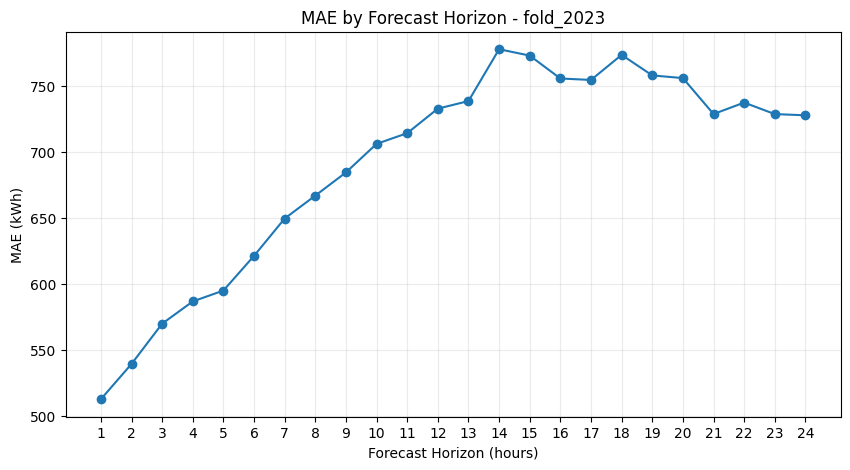

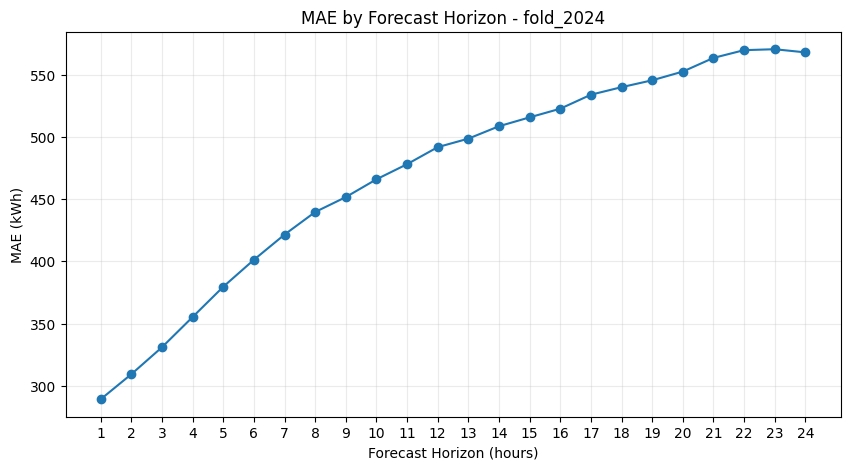

In [8]:
# MAE by Forecast Horizon
for fold, group in horizon_metrics.groupby("fold"):
    plt.figure(figsize=(10, 5))
    plt.plot(group["horizon"], group["mae"], marker="o")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("MAE (kWh)")
    plt.title(f"MAE by Forecast Horizon - {fold}")
    plt.xticks(range(1, 25))
    plt.grid(alpha=0.25)
    plt.show()


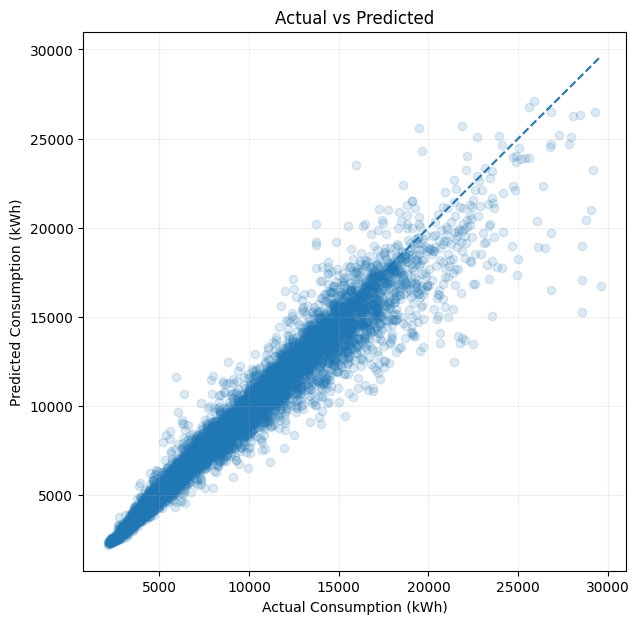

In [9]:
# Actual vs Predicted
sample = predictions.sample(n=min(10000, len(predictions)), random_state=42)
plt.figure(figsize=(7, 7))
plt.scatter(sample["actual"], sample["predicted"], alpha=0.15)
minimum = min(sample["actual"].min(), sample["predicted"].min())
maximum = max(sample["actual"].max(), sample["predicted"].max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.2)
plt.show()


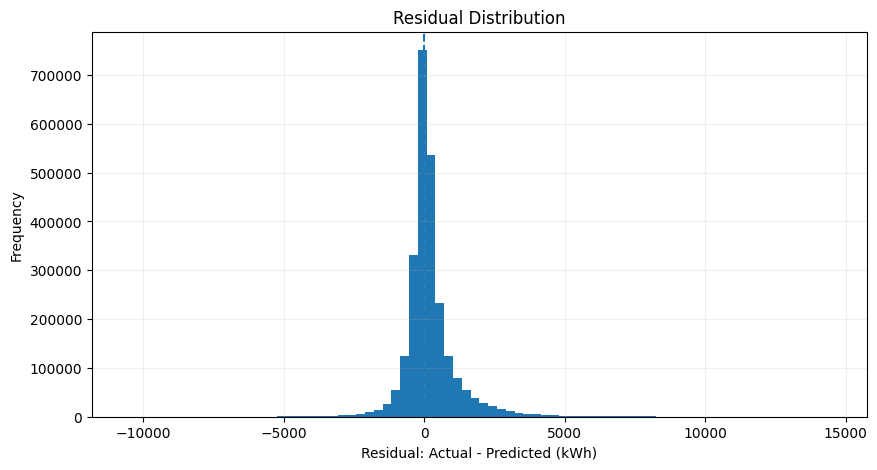

In [10]:
# Residual Distribution
plt.figure(figsize=(10, 5))
plt.hist(predictions["residual"].dropna(), bins=80)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual: Actual - Predicted (kWh)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(alpha=0.2)
plt.show()


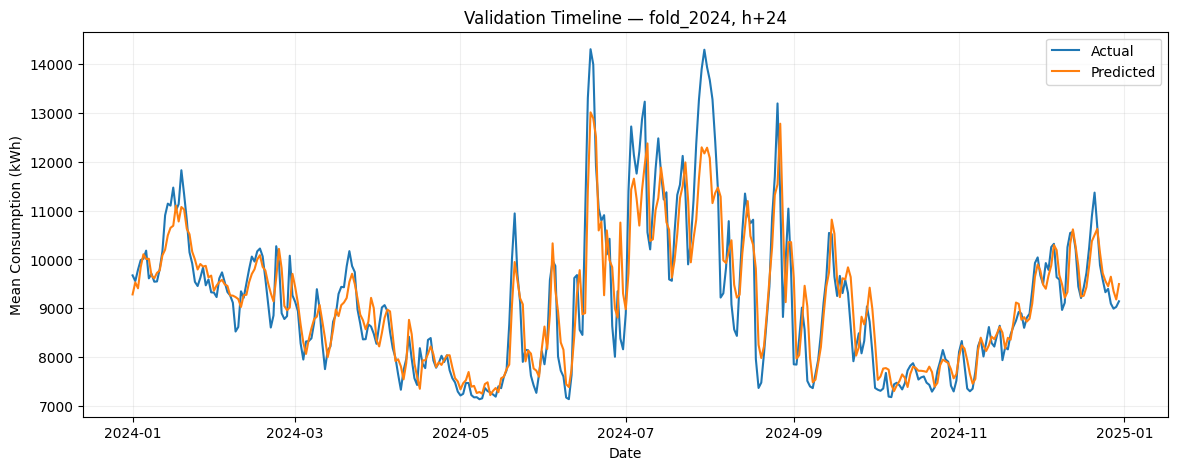

In [11]:
# Validation Timeline
timeline = predictions.query("fold == 'fold_2024' and horizon == 24").copy()
timeline["date"] = timeline["forecast_origin"].dt.floor("D")
daily = (
    timeline.groupby("date", observed=True)
    .agg(actual=("actual", "mean"), predicted=("predicted", "mean"))
    .reset_index()
)
plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["actual"], label="Actual")
plt.plot(daily["date"], daily["predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Mean Consumption (kWh)")
plt.title("Validation Timeline — fold_2024, h+24")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Additional Temporal and FSA Error Diagnostics

In [12]:
# Load previously generated LightGBM validation predictions.
# This section does not retrain the model.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "modeling"
    / "forecasting"
    / "lightgbm"
    / "lightgbm_validation_predictions.parquet"
)

predictions = pd.read_parquet(
    PREDICTIONS_PATH
)

predictions["forecast_origin"] = pd.to_datetime(
    predictions["forecast_origin"]
)

# Diagnostic residual convention:
# positive residual = underprediction
# negative residual = overprediction
predictions["residual"] = (
    predictions["actual"]
    - predictions["predicted"]
)

predictions["absolute_error"] = (
    predictions["residual"].abs()
)

predictions["absolute_percentage_error"] = np.where(
    predictions["actual"] != 0,
    predictions["absolute_error"]
    / predictions["actual"].abs()
    * 100,
    np.nan,
)

predictions["year"] = (
    predictions["forecast_origin"].dt.year
)

predictions["month_number"] = (
    predictions["forecast_origin"].dt.month
)

predictions["month_name"] = (
    predictions["forecast_origin"].dt.strftime("%b")
)

display(predictions.head())

print(
    f"Rows loaded: {len(predictions):,}"
)

print(
    f"FSAs: {sorted(predictions['fsa'].unique())}"
)

print(
    f"Folds: {sorted(predictions['fold'].unique())}"
)

,fold,fsa,forecast_origin,horizon,actual,predicted,residual,absolute_error,absolute_percentage_error,year,month_number,month_name
0,fold_2023,L4T,2023-01-01 00:00:00,1,8887.8,8554.340193,333.459807,333.459807,3.751882,2023,1,Ene.
1,fold_2023,L4T,2023-01-01 01:00:00,1,8343.7,7945.084993,398.615007,398.615007,4.777437,2023,1,Ene.
2,fold_2023,L4T,2023-01-01 02:00:00,1,8034.0,7674.919609,359.080391,359.080391,4.469509,2023,1,Ene.
3,fold_2023,L4T,2023-01-01 03:00:00,1,7736.1,7507.203596,228.896404,228.896404,2.958809,2023,1,Ene.
4,fold_2023,L4T,2023-01-01 04:00:00,1,7606.8,7445.430588,161.369412,161.369412,2.121384,2023,1,Ene.


Rows loaded: 2,519,424
FSAs: ['L4T', 'M5R', 'M5S', 'M6G', 'M9R', 'M9W']
Folds: ['fold_2023', 'fold_2024']


### Monthly metrics

In [13]:
# Calculate monthly validation metrics.
monthly_metrics = (
    predictions
    .groupby(
        [
            "fold",
            "year",
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "fold",
            "year",
            "month_number",
        ]
    )
)

display(monthly_metrics)

,fold,year,month_number,month_name,observations,mae,mape,mean_residual,actual_mean,predicted_mean
0,fold_2023,2023,1,Ene.,107136,469.800993,4.566219,233.772021,9689.395584,9455.623563
1,fold_2023,2023,2,Feb.,96768,595.124649,5.672183,276.003656,9756.330448,9480.326792
2,fold_2023,2023,3,Mar.,107136,543.951212,5.519186,247.586083,9208.743095,8961.157012
3,fold_2023,2023,4,Abr.,103680,503.797078,5.559495,290.587666,8088.189191,7797.601525
4,fold_2023,2023,5,May.,107136,552.676408,5.694957,382.596579,7730.152050,7347.555471
5,fold_2023,2023,6,Jun.,103680,900.834203,8.190657,496.811326,9050.545692,8553.734365
6,fold_2023,2023,7,Jul.,107136,1326.932133,10.481659,697.295763,10847.802063,10150.506300
7,fold_2023,2023,8,Ago.,107136,1019.777208,9.481504,434.605543,9338.000313,8903.394770
8,fold_2023,2023,9,Set.,103680,945.196037,8.311030,697.933734,8715.273743,8017.340009
9,fold_2023,2023,10,Oct.,107136,514.398156,5.531205,290.552253,7912.513776,7621.961523


### Monthly MAE

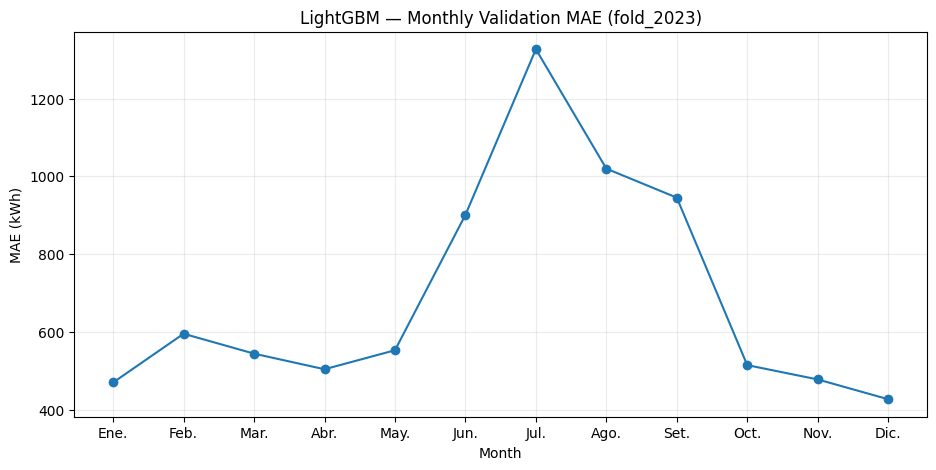

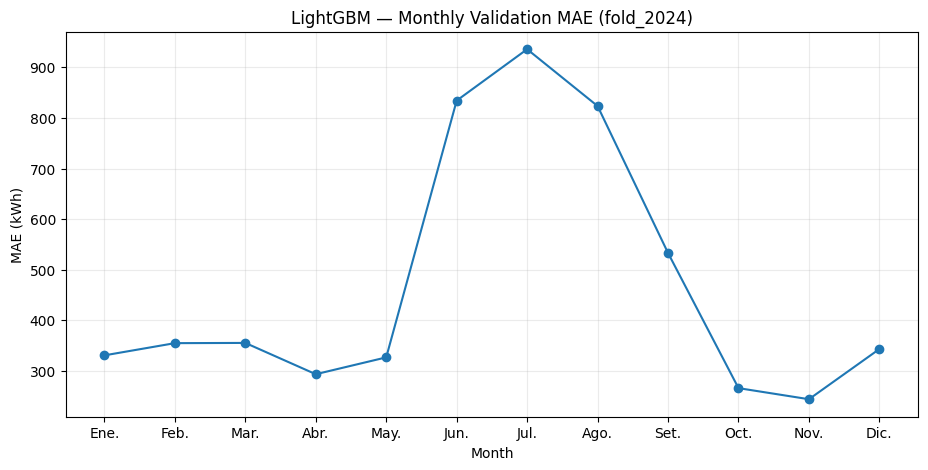

In [14]:
# Plot monthly MAE for each validation fold.
for fold, group in monthly_metrics.groupby(
    "fold"
):

    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        group["month_name"],
        group["mae"],
        marker="o",
    )

    plt.xlabel("Month")
    plt.ylabel("MAE (kWh)")

    plt.title(
        f"LightGBM — Monthly Validation MAE ({fold})"
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()

### Monthly residual

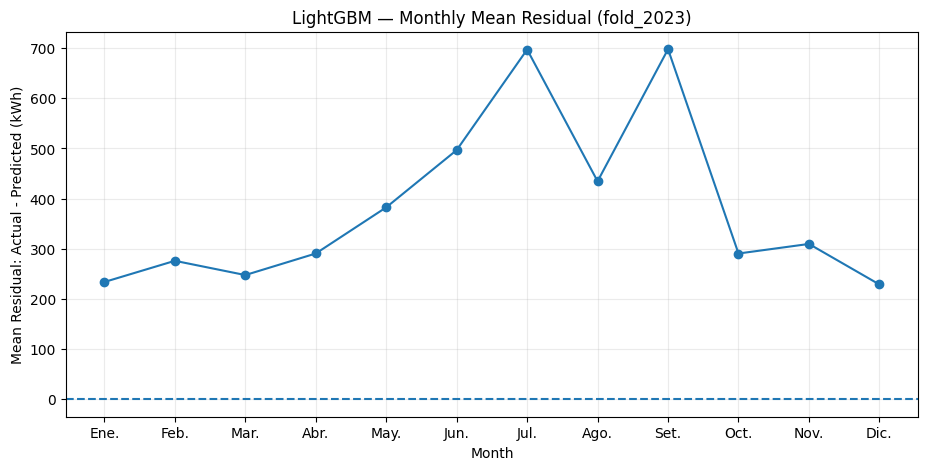

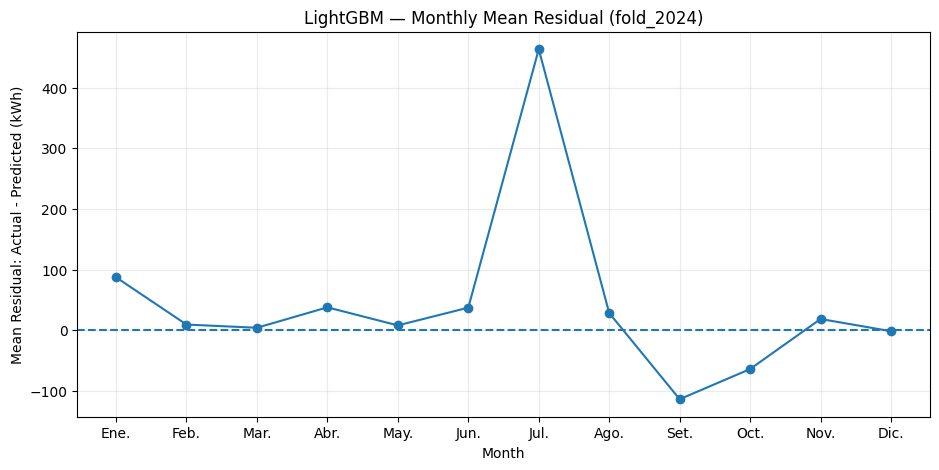

In [15]:
# Plot monthly mean residual.
for fold, group in monthly_metrics.groupby(
    "fold"
):

    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        group["month_name"],
        group["mean_residual"],
        marker="o",
    )

    plt.axhline(
        0,
        linestyle="--",
    )

    plt.xlabel("Month")

    plt.ylabel(
        "Mean Residual: Actual - Predicted (kWh)"
    )

    plt.title(
        f"LightGBM — Monthly Mean Residual ({fold})"
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()

### Monthly metrics × FSA

In [16]:
# Calculate monthly validation metrics by FSA.
monthly_fsa_metrics = (
    predictions
    .groupby(
        [
            "fold",
            "year",
            "month_number",
            "month_name",
            "fsa",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "fold",
            "fsa",
            "year",
            "month_number",
        ]
    )
)

display(
    monthly_fsa_metrics.head(30)
)

,fold,year,month_number,month_name,fsa,observations,mae,mape,mean_residual,actual_mean,predicted_mean
0,fold_2023,2023,1,Ene.,L4T,17856,300.977950,2.686219,66.335686,11266.489830,11200.154144
6,fold_2023,2023,2,Feb.,L4T,16128,400.710171,3.477177,26.787369,11317.397371,11290.610002
12,fold_2023,2023,3,Mar.,L4T,17856,368.968395,3.389129,67.586931,10798.958205,10731.371274
18,fold_2023,2023,4,Abr.,L4T,17280,384.108389,3.830419,207.942796,9954.833657,9746.890861
24,fold_2023,2023,5,May.,L4T,17856,471.088034,4.412139,307.480958,9962.615541,9655.134583
30,fold_2023,2023,6,Jun.,L4T,17280,917.305333,7.228863,181.234405,12019.116024,11837.881619
36,fold_2023,2023,7,Jul.,L4T,17856,1371.815857,9.409593,27.318944,14512.347278,14485.028335
42,fold_2023,2023,8,Ago.,L4T,17856,1133.337738,8.799910,78.856930,12565.724222,12486.867291
48,fold_2023,2023,9,Set.,L4T,17280,947.314169,6.884346,573.275005,11511.567205,10938.292200
54,fold_2023,2023,10,Oct.,L4T,17856,402.082430,3.809623,130.800987,10010.141969,9879.340982


In [17]:
OUTPUT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "forecasting"
    / "lightgbm"
    / "LGBM_05_monthly_fsa_metrics.csv"
)

monthly_fsa_metrics.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(
    f"Saved: {OUTPUT_PATH}"
)

Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\modeling\forecasting\lightgbm\LGBM_05_monthly_fsa_metrics.csv


### Heatmap FSA × Month

In [18]:
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

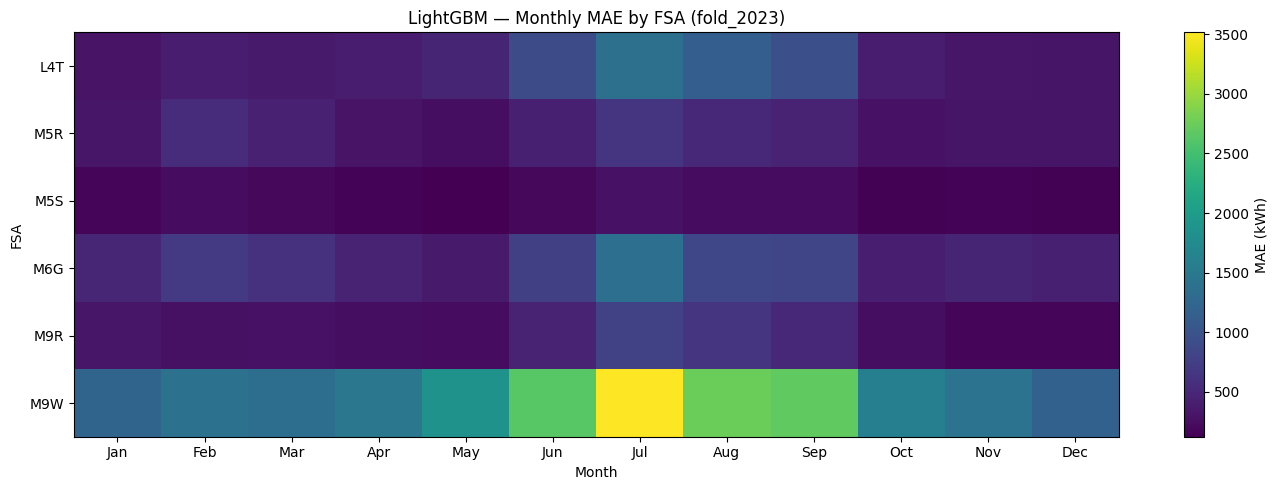

In [19]:
# Heatmap of monthly MAE by FSA — fold_2023.
heatmap_2023 = (
    monthly_fsa_metrics[
        monthly_fsa_metrics["fold"]
        == "fold_2023"
    ]
    .pivot(
        index="fsa",
        columns="month_number",
        values="mae",
    )
)

plt.figure(
    figsize=(14, 5)
)

image = plt.imshow(
    heatmap_2023.values,
    aspect="auto",
)

plt.yticks(
    range(len(heatmap_2023.index)),
    heatmap_2023.index,
)

plt.xticks(
    range(12),
    month_labels,
)

plt.xlabel("Month")
plt.ylabel("FSA")

plt.title(
    "LightGBM — Monthly MAE by FSA (fold_2023)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

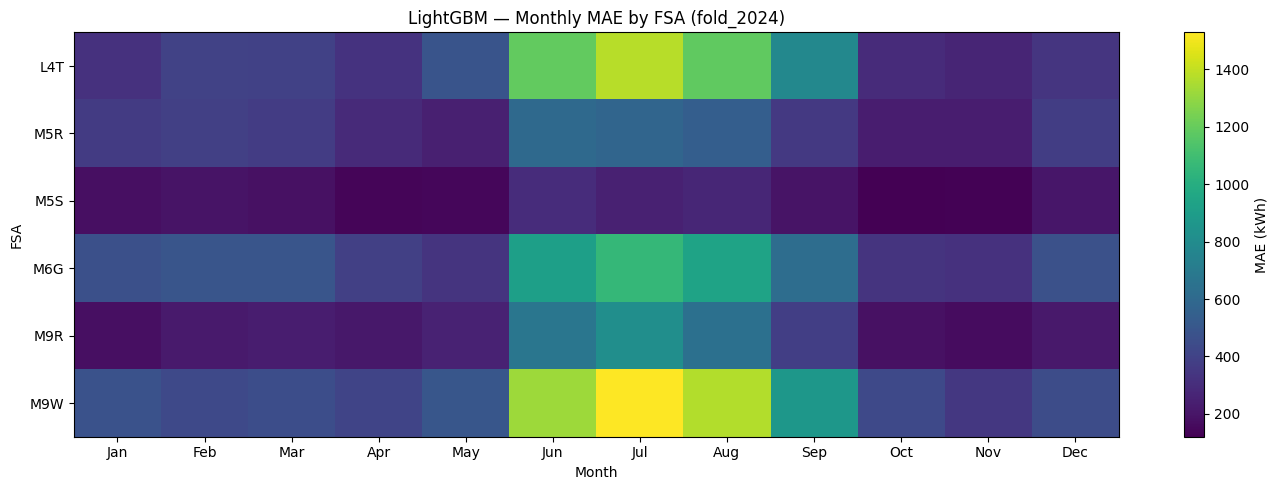

In [20]:
# Heatmap of monthly MAE by FSA — fold_2024.
heatmap_2024 = (
    monthly_fsa_metrics[
        monthly_fsa_metrics["fold"]
        == "fold_2024"
    ]
    .pivot(
        index="fsa",
        columns="month_number",
        values="mae",
    )
)

plt.figure(
    figsize=(14, 5)
)

image = plt.imshow(
    heatmap_2024.values,
    aspect="auto",
)

plt.yticks(
    range(len(heatmap_2024.index)),
    heatmap_2024.index,
)

plt.xticks(
    range(12),
    month_labels,
)

plt.xlabel("Month")
plt.ylabel("FSA")

plt.title(
    "LightGBM — Monthly MAE by FSA (fold_2024)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### Heatmap FSA × Fold

In [21]:
# Calculate MAE by FSA and validation fold.
fsa_fold_mae = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

display(
    fsa_fold_mae
)

,fold,fsa,mae
0,fold_2023,L4T,613.518339
1,fold_2023,M5R,402.510541
2,fold_2023,M5S,191.419539
3,fold_2023,M6G,644.135258
4,fold_2023,M9R,366.854071
5,fold_2023,M9W,1927.861771
6,fold_2024,L4T,615.170779
7,fold_2024,M5R,381.399300
8,fold_2024,M5S,193.263539
9,fold_2024,M6G,569.328730


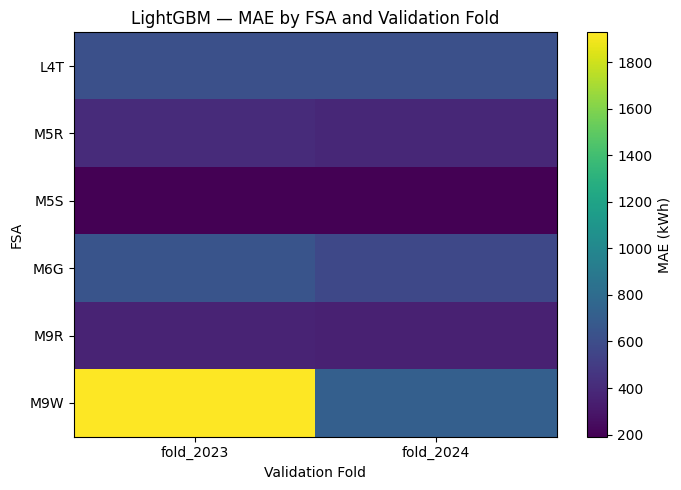

In [22]:
fsa_fold_pivot = (
    fsa_fold_mae
    .pivot(
        index="fsa",
        columns="fold",
        values="mae",
    )
)

plt.figure(
    figsize=(7, 5)
)

image = plt.imshow(
    fsa_fold_pivot.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_fold_pivot.index)),
    fsa_fold_pivot.index,
)

plt.xticks(
    range(len(fsa_fold_pivot.columns)),
    fsa_fold_pivot.columns,
)

plt.xlabel(
    "Validation Fold"
)

plt.ylabel(
    "FSA"
)

plt.title(
    "LightGBM — MAE by FSA and Validation Fold"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### FSA × Horizon

In [23]:
# Calculate MAE by FSA and forecast horizon.

fsa_horizon_mae = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
            "horizon",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

display(
    fsa_horizon_mae.head()
)

,fold,fsa,horizon,mae
0,fold_2023,L4T,1,362.398353
1,fold_2023,L4T,2,387.389895
2,fold_2023,L4T,3,415.929712
3,fold_2023,L4T,4,456.609175
4,fold_2023,L4T,5,484.679298


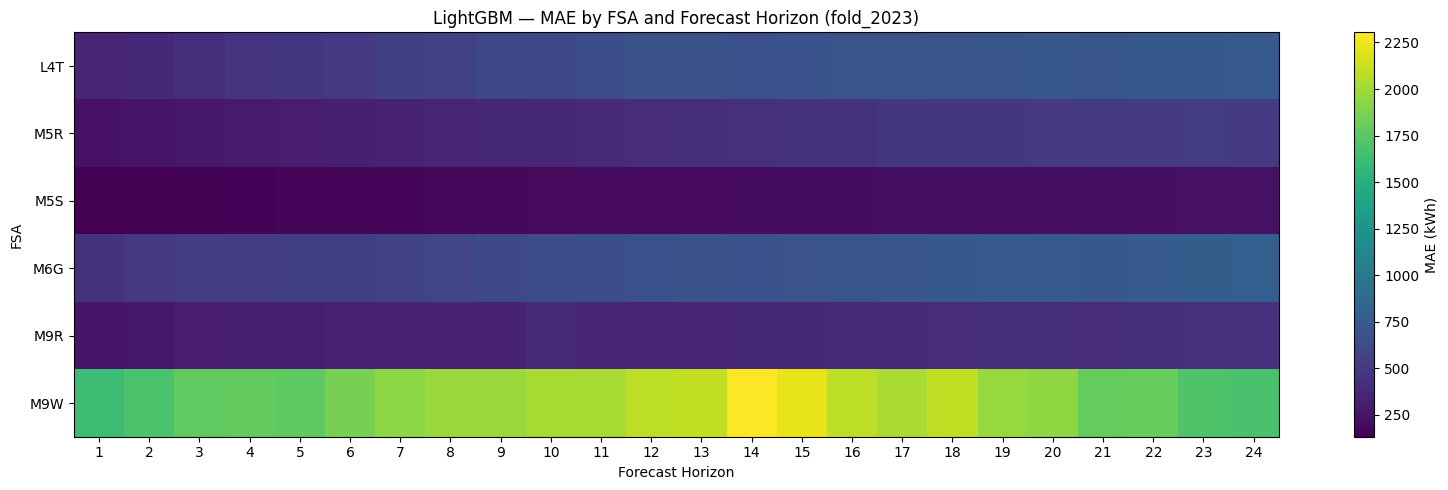

In [24]:
fsa_horizon_2023 = (
    fsa_horizon_mae[
        fsa_horizon_mae["fold"]
        == "fold_2023"
    ]
    .pivot(
        index="fsa",
        columns="horizon",
        values="mae",
    )
)

plt.figure(
    figsize=(16, 5)
)

image = plt.imshow(
    fsa_horizon_2023.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_horizon_2023.index)),
    fsa_horizon_2023.index,
)

plt.xticks(
    range(24),
    range(1, 25),
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "FSA"
)

plt.title(
    "LightGBM — MAE by FSA and Forecast Horizon (fold_2023)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

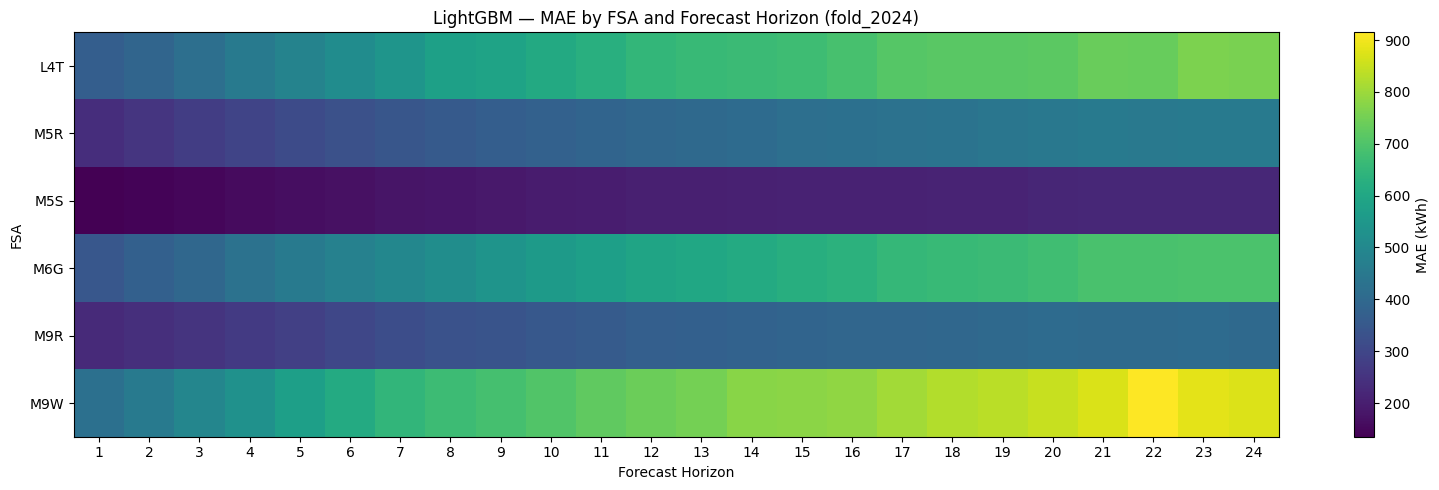

In [25]:
fsa_horizon_2024 = (
    fsa_horizon_mae[
        fsa_horizon_mae["fold"]
        == "fold_2024"
    ]
    .pivot(
        index="fsa",
        columns="horizon",
        values="mae",
    )
)

plt.figure(
    figsize=(16, 5)
)

image = plt.imshow(
    fsa_horizon_2024.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_horizon_2024.index)),
    fsa_horizon_2024.index,
)

plt.xticks(
    range(24),
    range(1, 25),
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "FSA"
)

plt.title(
    "LightGBM — MAE by FSA and Forecast Horizon (fold_2024)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### M9W-2023 analysis

In [26]:
# Isolate M9W during fold_2023.
m9w_2023 = (
    predictions[
        (
            predictions["fold"]
            == "fold_2023"
        )
        & (
            predictions["fsa"]
            == "M9W"
        )
    ]
    .copy()
)

print(
    f"M9W-2023 observations: {len(m9w_2023):,}"
)

display(
    m9w_2023.head()
)

M9W-2023 observations: 209,664


,fold,fsa,forecast_origin,horizon,actual,predicted,residual,absolute_error,absolute_percentage_error,year,month_number,month_name
43680,fold_2023,M9W,2023-01-01 00:00:00,1,10386.7,9554.792714,831.907286,831.907286,8.009351,2023,1,Ene.
43681,fold_2023,M9W,2023-01-01 01:00:00,1,9824.2,8828.566653,995.633347,995.633347,10.134498,2023,1,Ene.
43682,fold_2023,M9W,2023-01-01 02:00:00,1,9433.5,8556.227179,877.272821,877.272821,9.299548,2023,1,Ene.
43683,fold_2023,M9W,2023-01-01 03:00:00,1,9162.5,8537.010727,625.489273,625.489273,6.826622,2023,1,Ene.
43684,fold_2023,M9W,2023-01-01 04:00:00,1,9096.0,8627.668032,468.331968,468.331968,5.148768,2023,1,Ene.


In [27]:
m9w_2023_summary = pd.DataFrame(
    [
        {
            "observations": len(m9w_2023),

            "actual_mean":
                m9w_2023["actual"].mean(),

            "predicted_mean":
                m9w_2023["predicted"].mean(),

            "mae":
                m9w_2023["absolute_error"].mean(),

            "mape":
                m9w_2023[
                    "absolute_percentage_error"
                ].mean(),

            "mean_residual":
                m9w_2023["residual"].mean(),

            "median_residual":
                m9w_2023["residual"].median(),

            "p95_absolute_error":
                m9w_2023[
                    "absolute_error"
                ].quantile(0.95),

            "maximum_absolute_error":
                m9w_2023[
                    "absolute_error"
                ].max(),
        }
    ]
)

display(
    m9w_2023_summary
)

,observations,actual_mean,predicted_mean,mae,mape,mean_residual,median_residual,p95_absolute_error,maximum_absolute_error
0,209664,14259.203217,12373.410615,1927.861771,12.805577,1885.792602,1501.432418,5232.16509,14500.995251


### M9W monthly analysis

In [28]:
m9w_2023_monthly = (
    m9w_2023
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
    .sort_values(
        "month_number"
    )
)

display(
    m9w_2023_monthly
)

,month_number,month_name,observations,actual_mean,predicted_mean,mae,mape,mean_residual
0,1,Ene.,17856,14738.861598,13566.529776,1213.645586,8.081201,1172.331823
1,2,Feb.,16128,14916.540960,13538.131991,1393.621519,9.180109,1378.408968
2,3,Mar.,17856,14345.509050,13027.461726,1352.791158,9.326894,1318.047324
3,4,Abr.,17280,13025.586580,11566.686696,1471.056508,11.119423,1458.899884
4,5,May.,17856,12669.597665,10807.434590,1868.793506,13.967972,1862.163074
5,6,Jun.,17280,14427.741134,11853.262908,2631.158543,17.395738,2574.478226
6,7,Jul.,17856,16919.120934,13598.496876,3514.573090,19.236676,3320.624058
7,8,Ago.,17856,14915.903584,12232.090747,2758.321102,17.672401,2683.812838
8,9,Set.,17280,13939.556667,11263.902435,2681.733573,17.577847,2675.654231
9,10,Oct.,17856,12769.972961,11198.918412,1585.378803,11.820145,1571.054549


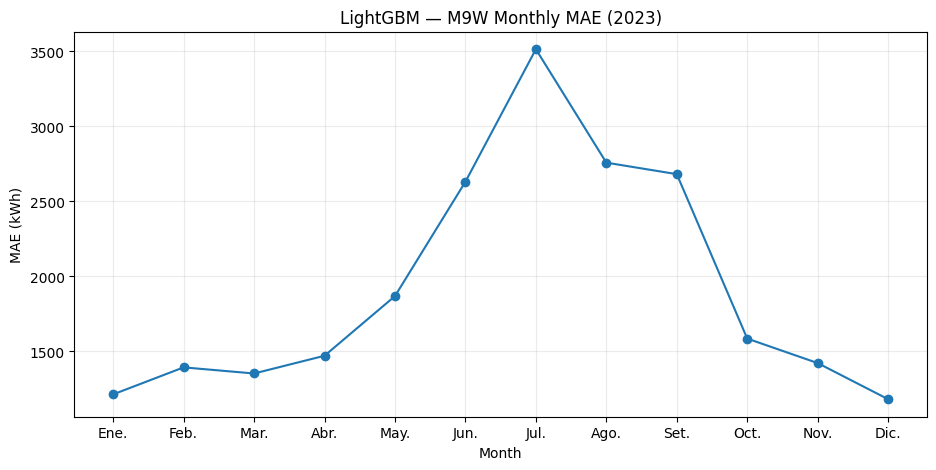

In [29]:
plt.figure(
    figsize=(11, 5)
)

plt.plot(
    m9w_2023_monthly["month_name"],
    m9w_2023_monthly["mae"],
    marker="o",
)

plt.xlabel("Month")
plt.ylabel("MAE (kWh)")

plt.title(
    "LightGBM — M9W Monthly MAE (2023)"
)

plt.grid(
    alpha=0.25
)

plt.show()

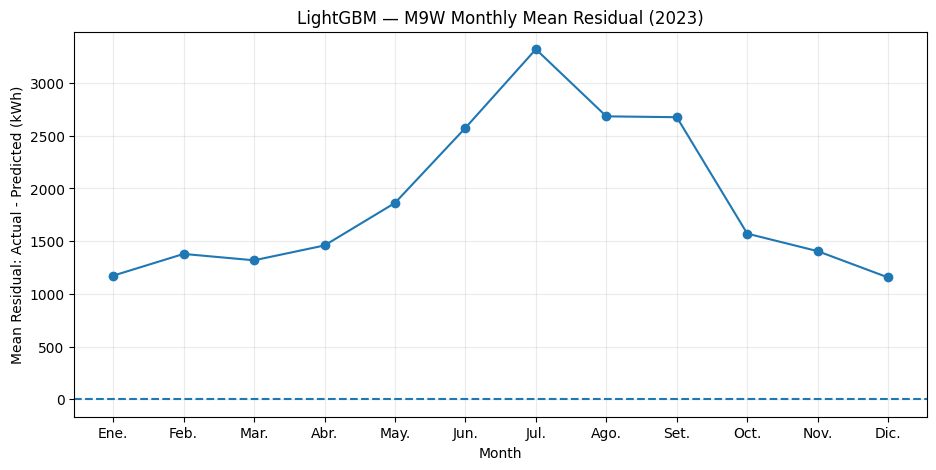

In [30]:
plt.figure(
    figsize=(11, 5)
)

plt.plot(
    m9w_2023_monthly["month_name"],
    m9w_2023_monthly["mean_residual"],
    marker="o",
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Month")

plt.ylabel(
    "Mean Residual: Actual - Predicted (kWh)"
)

plt.title(
    "LightGBM — M9W Monthly Mean Residual (2023)"
)

plt.grid(
    alpha=0.25
)

plt.show()

### M9W Actual vs Predicted timeline

In [31]:
m9w_h24 = (
    m9w_2023[
        m9w_2023["horizon"] == 24
    ]
    .sort_values(
        "forecast_origin"
    )
    .copy()
)

m9w_h24["date"] = (
    m9w_h24[
        "forecast_origin"
    ]
    .dt.floor("D")
)

m9w_h24_daily = (
    m9w_h24
    .groupby(
        "date",
        observed=True,
    )
    .agg(
        actual=("actual", "mean"),
        predicted=("predicted", "mean"),
    )
    .reset_index()
)

display(
    m9w_h24_daily.head()
)

,date,actual,predicted
0,2023-01-01,12148.604167,12338.545048
1,2023-01-02,12896.716667,12592.041523
2,2023-01-03,14120.195833,13120.978719
3,2023-01-04,14381.362500,14059.311363
4,2023-01-05,14339.466667,14359.279883


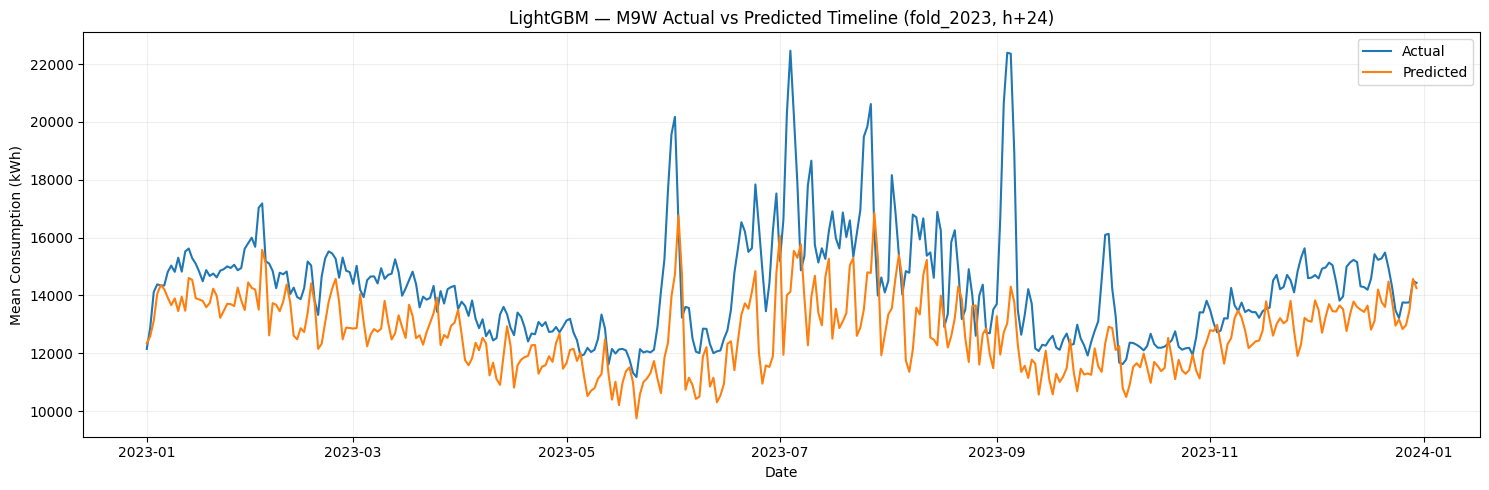

In [32]:
plt.figure(
    figsize=(15, 5)
)

plt.plot(
    m9w_h24_daily["date"],
    m9w_h24_daily["actual"],
    label="Actual",
)

plt.plot(
    m9w_h24_daily["date"],
    m9w_h24_daily["predicted"],
    label="Predicted",
)

plt.xlabel("Date")
plt.ylabel(
    "Mean Consumption (kWh)"
)

plt.title(
    "LightGBM — M9W Actual vs Predicted Timeline "
    "(fold_2023, h+24)"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

### M9W residual timeline

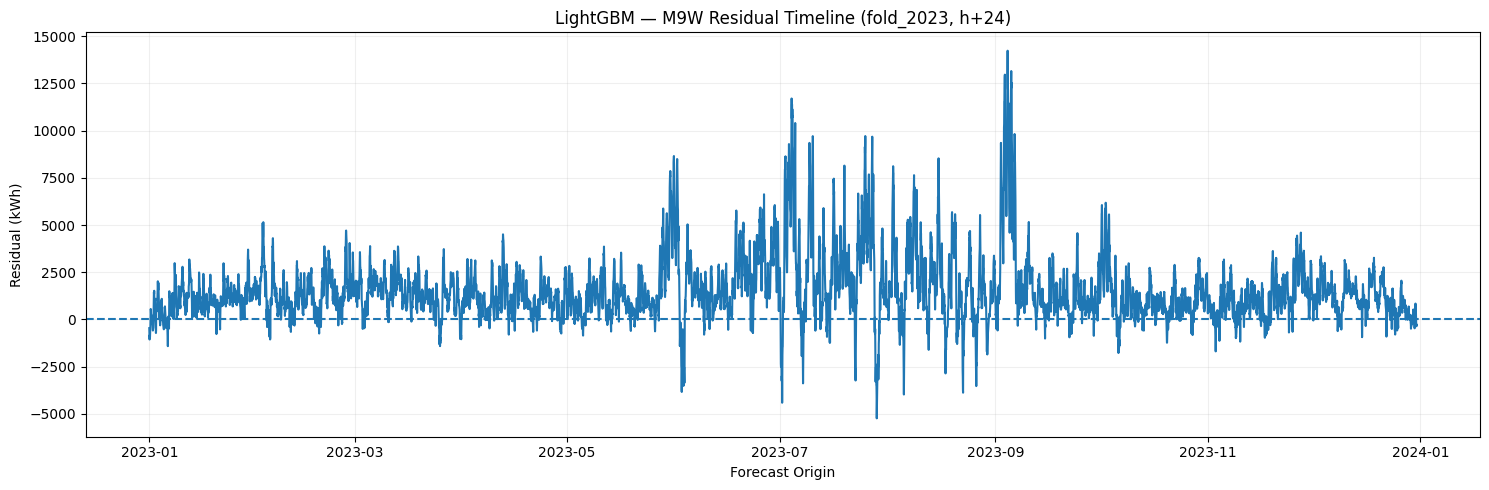

In [33]:
m9w_h24["residual"] = (
    m9w_h24["actual"]
    - m9w_h24["predicted"]
)

plt.figure(
    figsize=(15, 5)
)

plt.plot(
    m9w_h24["forecast_origin"],
    m9w_h24["residual"],
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel(
    "Forecast Origin"
)

plt.ylabel(
    "Residual (kWh)"
)

plt.title(
    "LightGBM — M9W Residual Timeline "
    "(fold_2023, h+24)"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

### Actual vs Predicted monthly level

In [34]:
m9w_level_comparison = (
    m9w_2023
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        "month_number"
    )
)

m9w_level_comparison[
    "difference_kwh"
] = (
    m9w_level_comparison["actual_mean"]
    - m9w_level_comparison["predicted_mean"]
)

m9w_level_comparison[
    "difference_pct"
] = (
    m9w_level_comparison[
        "difference_kwh"
    ]
    / m9w_level_comparison[
        "actual_mean"
    ]
    * 100
)

display(
    m9w_level_comparison
)

,month_number,month_name,actual_mean,predicted_mean,difference_kwh,difference_pct
0,1,Ene.,14738.861598,13566.529776,1172.331823,7.954019
1,2,Feb.,14916.540960,13538.131991,1378.408968,9.240808
2,3,Mar.,14345.509050,13027.461726,1318.047324,9.187874
3,4,Abr.,13025.586580,11566.686696,1458.899884,11.200262
4,5,May.,12669.597665,10807.434590,1862.163074,14.697886
5,6,Jun.,14427.741134,11853.262908,2574.478226,17.843945
6,7,Jul.,16919.120934,13598.496876,3320.624058,19.626457
7,8,Ago.,14915.903584,12232.090747,2683.812838,17.992962
8,9,Set.,13939.556667,11263.902435,2675.654231,19.194687
9,10,Oct.,12769.972961,11198.918412,1571.054549,12.302724


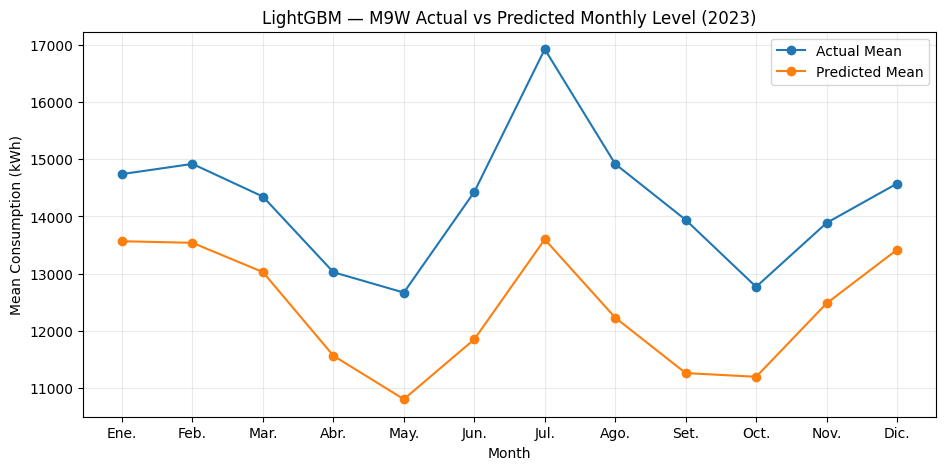

In [35]:
plt.figure(
    figsize=(11, 5)
)

plt.plot(
    m9w_level_comparison["month_name"],
    m9w_level_comparison["actual_mean"],
    marker="o",
    label="Actual Mean",
)

plt.plot(
    m9w_level_comparison["month_name"],
    m9w_level_comparison["predicted_mean"],
    marker="o",
    label="Predicted Mean",
)

plt.xlabel("Month")

plt.ylabel(
    "Mean Consumption (kWh)"
)

plt.title(
    "LightGBM — M9W Actual vs Predicted Monthly Level (2023)"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

### M9W vs remaining FSAs

In [36]:
comparison_2023 = (
    predictions[
        predictions["fold"]
        == "fold_2023"
    ]
    .copy()
)

comparison_2023[
    "group"
] = np.where(
    comparison_2023["fsa"]
    == "M9W",
    "M9W",
    "Other FSAs",
)

m9w_vs_others = (
    comparison_2023
    .groupby(
        "group",
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(
    m9w_vs_others
)

,group,observations,actual_mean,predicted_mean,mae,mape,mean_residual
0,M9W,209664,14259.203217,12373.410615,1927.861771,12.805577,1885.792602
1,Other FSAs,1048320,7977.667853,7895.531476,443.687549,5.248987,82.136377


### MAE por temperature folds.

In [37]:
# Optional diagnostic:
# compare forecasting error across temperature bands.

FEATURE_DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "feature_dataset.parquet"
)

feature_data = pd.read_parquet(
    FEATURE_DATASET_PATH,
    columns=[
        "fsa",
        "timestamp",
        "Temp (°C)",
    ],
)

feature_data["timestamp"] = pd.to_datetime(
    feature_data["timestamp"]
)

temperature_lookup = feature_data.rename(
    columns={
        "timestamp": "forecast_origin",
        "Temp (°C)": "temperature",
    }
)

temperature_predictions = predictions.merge(
    temperature_lookup,
    on=[
        "fsa",
        "forecast_origin",
    ],
    how="left",
)

temperature_predictions[
    "temperature_band"
] = pd.cut(
    temperature_predictions["temperature"],
    bins=[
        -np.inf,
        -10,
        0,
        10,
        20,
        25,
        30,
        np.inf,
    ],
    labels=[
        "< -10°C",
        "-10 to 0°C",
        "0 to 10°C",
        "10 to 20°C",
        "20 to 25°C",
        "25 to 30°C",
        "> 30°C",
    ],
)

temperature_error = (
    temperature_predictions
    .groupby(
        "temperature_band",
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
    )
    .reset_index()
)

display(
    temperature_error
)

,temperature_band,observations,mae,mape
0,< -10°C,23112,572.076589,4.742107
1,-10 to 0°C,329904,442.732798,4.259857
2,0 to 10°C,882936,391.429574,4.323942
3,10 to 20°C,745992,573.937185,6.071550
4,20 to 25°C,410688,933.248833,8.386793
5,25 to 30°C,118296,1125.390749,8.876828
6,> 30°C,7416,1709.581414,10.804147


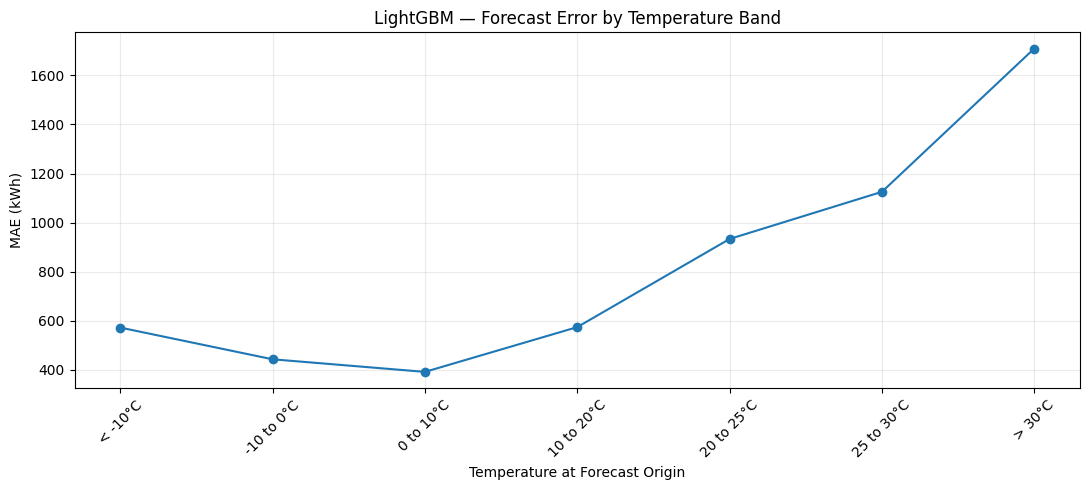

In [38]:
plt.figure(
    figsize=(11, 5)
)

plt.plot(
    temperature_error[
        "temperature_band"
    ].astype(str),
    temperature_error["mae"],
    marker="o",
)

plt.xlabel(
    "Temperature at Forecast Origin"
)

plt.ylabel(
    "MAE (kWh)"
)

plt.title(
    "LightGBM — Forecast Error by Temperature Band"
)

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()